In [223]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import root_mean_squared_error, r2_score

%matplotlib inline

In [224]:
df_2020 = pd.read_csv('data/nuremberg_2020_20m_polygons.csv')
df_2021 = pd.read_csv('data/nuremberg_2021_20m_polygons.csv')

In [225]:
df_2020.columns

Index(['system:index', 'B11', 'B12', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8',
       'bare_sparse_vegetation', 'built_up', 'cell_id', 'cropland',
       'grassland', 'image_count', 'tree_cover', 'water', 'x', 'y', 'year',
       '.geo'],
      dtype='str')

In [226]:
df_2020.dtypes

system:index                int64
B11                       float64
B12                       float64
B2                        float64
B3                        float64
B4                        float64
B5                        float64
B6                        float64
B7                        float64
B8                        float64
bare_sparse_vegetation    float64
built_up                  float64
cell_id                       str
cropland                  float64
grassland                 float64
image_count                 int64
tree_cover                float64
water                     float64
x                         float64
y                         float64
year                        int64
.geo                          str
dtype: object

In [227]:
df_2020 = df_2020.drop(columns=['system:index', 'image_count', '.geo', 'year', 'cell_id'])
df_2020 = df_2020.fillna(df_2020.mean())

df_2021 = df_2021.drop(columns=['system:index', 'image_count', '.geo', 'year', 'cell_id'])
df_2021 = df_2021.fillna(df_2021.mean())

In [228]:
# B1, B9, B10

In [229]:
# mean_median_cols = [col for col in df_2020.columns if ('_median' in col)]
# excluded_bands = [col for col in df_2020 if not ('B1_' in col or 'B9_' in col or 'B8A' in col or 'B10_' in col)]

# df_2020['vegetation'] = df_2020[['tree_cover', 'cropland', 'grassland']].sum(axis=1)
# df_2021['vegetation'] = df_2021[['tree_cover', 'cropland', 'grassland']].sum(axis=1)

target_labels = [
    'built_up',
    'tree_cover',
    'grassland',
    'cropland',
    'water'
]

remaining_target = [
    'bare_sparse_vegetation'
]

# sel_col = excluded_bands
# df_2020 = df_2020[sel_col]
# df_2021 = df_2021[sel_col]

In [230]:
df_2020.columns

Index(['B11', 'B12', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8',
       'bare_sparse_vegetation', 'built_up', 'cropland', 'grassland',
       'tree_cover', 'water', 'x', 'y'],
      dtype='str')

In [231]:
# --- Feature Engineering for df_2020 ---
# Vegetation Indices
df_2020['NDVI'] = (df_2020['B8'] - df_2020['B4']) / (df_2020['B8'] + df_2020['B4'] + 1e-8)
df_2020['EVI'] = 2.5 * ((df_2020['B8'] - df_2020['B4']) / (df_2020['B8'] + 6 * df_2020['B4'] - 7.5 * df_2020['B2'] + 1 + 1e-8))
# df_2020['SAVI'] = ((df_2020['B8'] - df_2020['B4']) * 1.5) / (df_2020['B8'] + df_2020['B4'] + 0.5 + 1e-8)
# df_2020['GNDVI'] = (df_2020['B8'] - df_2020['B3']) / (df_2020['B8'] + df_2020['B3'] + 1e-8)

# Urban & Built-up Indices
df_2020['NDBI'] = (df_2020['B11'] - df_2020['B8']) / (df_2020['B11'] + df_2020['B8'] + 1e-8)

# Water & Moisture Indices
df_2020['NDWI'] = (df_2020['B3'] - df_2020['B8']) / (df_2020['B3'] + df_2020['B8'] + 1e-8)
df_2020['MNDWI'] = (df_2020['B3'] - df_2020['B11']) / (df_2020['B3'] + df_2020['B11'] + 1e-8)


# --- Feature Engineering for df_2021 ---
# Vegetation Indices
df_2021['NDVI'] = (df_2021['B8'] - df_2021['B4']) / (df_2021['B8'] + df_2021['B4'] + 1e-8)
df_2021['EVI'] = 2.5 * ((df_2021['B8'] - df_2021['B4']) / (df_2021['B8'] + 6 * df_2021['B4'] - 7.5 * df_2021['B2'] + 1 + 1e-8))
# df_2021['SAVI'] = ((df_2021['B8'] - df_2021['B4']) * 1.5) / (df_2021['B8'] + df_2021['B4'] + 0.5 + 1e-8)
# df_2021['GNDVI'] = (df_2021['B8'] - df_2021['B3']) / (df_2021['B8'] + df_2021['B3'] + 1e-8)

# Urban & Built-up Indices
df_2021['NDBI'] = (df_2021['B11'] - df_2021['B8']) / (df_2021['B11'] + df_2021['B8'] + 1e-8)

# Water & Moisture Indices
df_2021['NDWI'] = (df_2021['B3'] - df_2021['B8']) / (df_2021['B3'] + df_2021['B8'] + 1e-8)
df_2021['MNDWI'] = (df_2021['B3'] - df_2021['B11']) / (df_2021['B3'] + df_2021['B11'] + 1e-8)

In [232]:
X_train = df_2020.drop(columns=target_labels + remaining_target)
X_train = X_train.drop(columns=['B4', 'B7', 'B8', 'NDBI'])
# X_train = df_2020[['B3_median', 'B8_median', 'B5_median', 'B6_median', 'B4_median', 'B11_median',  'NDVI']]
y_train = df_2020[target_labels]

X_test = df_2021.drop(columns=target_labels + remaining_target)
X_test = X_test.drop(columns=['B4', 'B7', 'B8', 'NDBI'])
# X_test = df_2021[['B3_median', 'B8_median', 'B5_median', 'B6_median', 'B4_median', 'B11_median',  'NDVI']]
y_test = df_2021[target_labels]

In [233]:
X_train.columns, y_train.columns

(Index(['B11', 'B12', 'B2', 'B3', 'B5', 'B6', 'x', 'y', 'NDVI', 'EVI', 'NDWI',
        'MNDWI'],
       dtype='str'),
 Index(['built_up', 'tree_cover', 'grassland', 'cropland', 'water'], dtype='str'))

In [234]:
def evaluate_regression_model(model_name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_rmse = root_mean_squared_error(y_train, y_train_pred)
    train_r2 = r2_score(y_train, y_train_pred)

    test_rmse = root_mean_squared_error(y_test, y_test_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    print(f"--- {model_name} ---")
    print(f"Train R2: {train_r2:.4f} | Test R2: {test_r2:.4f}")
    print(f"Train RMSE: {train_rmse:.4f} | Test RMSE: {test_rmse:.4f}\n")

    return {
        'Model': model_name,
        'Train RMSE': train_rmse,
        'Test RMSE': test_rmse,
        'Train R2': train_r2,
        'Test R2': test_r2
    }

In [235]:
from sklearn.multioutput import MultiOutputRegressor
from sklearn.svm import SVR

models = {
    "Linear Regression": Pipeline([("scaler", StandardScaler()), ("lr", LinearRegression())]),
    "Ridge Regression": Pipeline([("scaler", StandardScaler()), ("ridge", Ridge(alpha=1.0))]),
    "Lasso Regression": Pipeline([("scaler", StandardScaler()), ("lasso", Lasso(alpha=0.1, max_iter=10000))]),
    # "SVR": Pipeline([
    #     ("scaler", StandardScaler()),
    #     ("svr", MultiOutputRegressor(SVR(kernel='rbf', C=100, epsilon=0.1)))
    # ]),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10, n_jobs=-1),
    "XGBoost": MultiOutputRegressor(XGBRegressor(n_estimators=865, learning_rate=0.01, random_state=42,
                                                 max_depth=10,
                                                 gamma=0.02,
                                                 min_child_weight=4,
                                                 reg_alpha=2.098,
                                                 reg_lambda=1.31,
                                                 colsample_bytree=0.82,
                                                 subsample=0.88,
                                                 n_jobs=-1,
                                                 ),
                                    n_jobs=-1
                                    )
}

results = []
for name, model in models.items():
    res = evaluate_regression_model(name, model, X_train, X_test, y_train, y_test)
    results.append(res)


--- Linear Regression ---
Train R2: 0.5141 | Test R2: 0.4573
Train RMSE: 0.2076 | Test RMSE: 0.2230

--- Ridge Regression ---
Train R2: 0.5141 | Test R2: 0.4573
Train RMSE: 0.2076 | Test RMSE: 0.2230

--- Lasso Regression ---
Train R2: 0.2144 | Test R2: 0.2203
Train RMSE: 0.2582 | Test RMSE: 0.2591

--- Random Forest ---
Train R2: 0.7897 | Test R2: 0.6919
Train RMSE: 0.1407 | Test RMSE: 0.1745

--- XGBoost ---
Train R2: 0.8783 | Test R2: 0.7658
Train RMSE: 0.1075 | Test RMSE: 0.1533



In [236]:
summary_df = pd.DataFrame(results).sort_values(by='Test RMSE', ascending=True)
display(summary_df)

,Model,Train RMSE,Test RMSE,Train R2,Test R2
4,XGBoost,0.107479,0.153293,0.878302,0.765785
3,Random Forest,0.140747,0.174535,0.789704,0.691869
1,Ridge Regression,0.207643,0.222985,0.514130,0.457331
0,Linear Regression,0.207643,0.222986,0.514130,0.457326
2,Lasso Regression,0.258166,0.259147,0.214355,0.220268


In [237]:
selected_labels = [
    'tree_cover', 'built_up', 'grassland', 'cropland',
    'bare_sparse_vegetation', 'water'
]

pd.DataFrame({'mean': df_2020[selected_labels].mean(), 'std': df_2020[selected_labels].std()})

,mean,std
tree_cover,0.366616,0.438404
built_up,0.368465,0.435704
grassland,0.122122,0.287768
cropland,0.107917,0.294285
bare_sparse_vegetation,0.023656,0.119428
water,0.011117,0.098643


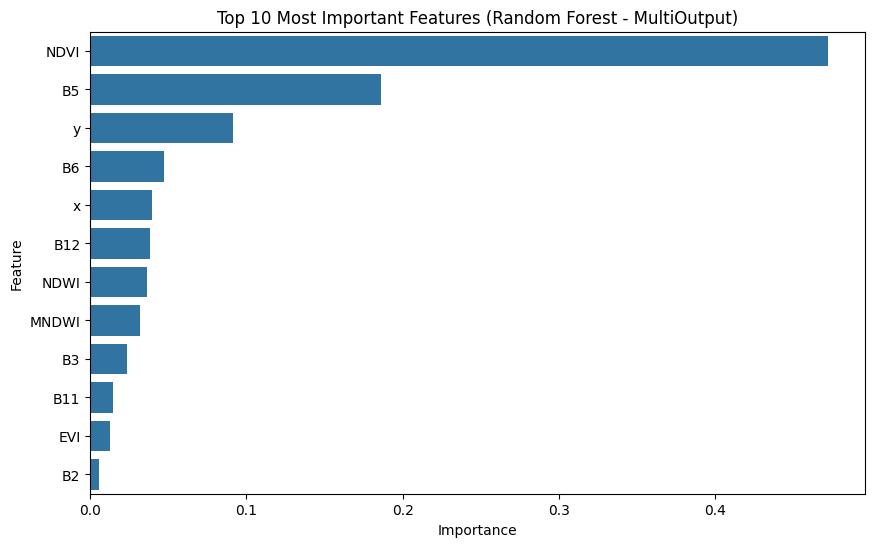

   Feature  Importance
8     NDVI    0.472439
4       B5    0.186439
7        y    0.091652
5       B6    0.047243
6        x    0.039420
1      B12    0.038014
10    NDWI    0.036451
11   MNDWI    0.032108
3       B3    0.023334
0      B11    0.014774
9      EVI    0.012577
2       B2    0.005548


In [238]:
feature_names = X_train.columns
importances = models['Random Forest'].feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Top 10 Most Important Features (Random Forest - MultiOutput)')
plt.show()

print(feature_importance_df)

,True_Dominant_Class,Pred_Dominant_Class,Match
0,grassland,tree_cover,False
1,tree_cover,tree_cover,True
2,built_up,built_up,True
3,built_up,built_up,True
4,built_up,built_up,True


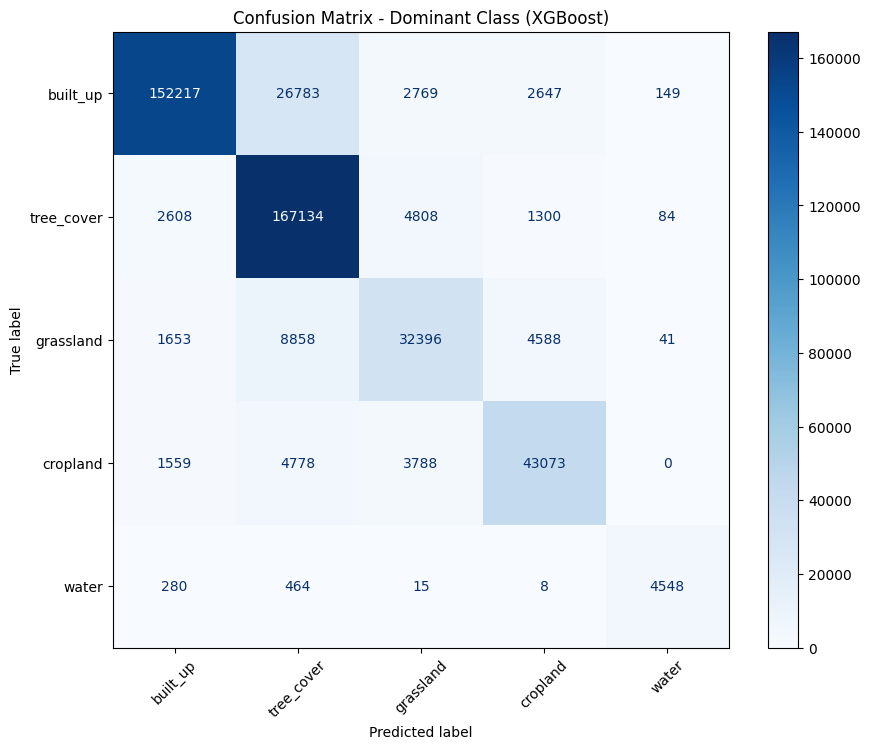

Overall Dominant Class Accuracy: 0.8560


In [239]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Use the labels actually used during training (4 labels in your current code)
current_labels = [
    # 'vegetation',
    'built_up',
    'tree_cover', 'grassland', 'cropland',
    # 'bare_sparse_vegetation',
    'water'
]

best_model_name = "XGBoost"
y_pred_array = models[best_model_name].predict(X_test)

# 2. Create DataFrame with the matching 4 columns
y_pred_df = pd.DataFrame(y_pred_array, columns=current_labels)

# 3. Get dominant classes
true_dominant = y_test[current_labels].idxmax(axis=1).reset_index(drop=True)
pred_dominant = y_pred_df.idxmax(axis=1)

# 4. Build comparison table
comparison_df = pd.DataFrame({
    'True_Dominant_Class': true_dominant,
    'Pred_Dominant_Class': pred_dominant
})
comparison_df['Match'] = comparison_df['True_Dominant_Class'] == comparison_df['Pred_Dominant_Class']

# 5. Output results
display(comparison_df.head(5))

# 6. Generate Confusion Matrix
cm = confusion_matrix(true_dominant, pred_dominant, labels=current_labels)
plt.figure(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=current_labels)
disp.plot(cmap='Blues', xticks_rotation=45, ax=plt.gca())
plt.title(f'Confusion Matrix - Dominant Class ({best_model_name})')
plt.show()

accuracy = comparison_df['Match'].mean()
print(f"Overall Dominant Class Accuracy: {accuracy:.4f}")

In [ ]:
import optuna
import numpy as np

from sklearn.model_selection import KFold, cross_val_score
from sklearn.multioutput import MultiOutputRegressor
from xgboost import XGBRegressor


def objective_xgboost(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 1000),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma": trial.suggest_float("gamma", 0.0, 5.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        "objective": "reg:squarederror",
        "random_state": 42,
        "n_jobs": -1,
        "tree_method": "hist",
    }

    model = MultiOutputRegressor(XGBRegressor(**params))

    cv = KFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1
    )

    return -scores.mean()


study = optuna.create_study(direction="minimize")
study.optimize(objective_xgboost, n_trials=25)

best_xgb_params = {
    **study.best_trial.params,
    "objective": "reg:squarederror",
    "random_state": 42,
    "n_jobs": -1,
    "tree_method": "hist",
}

model = MultiOutputRegressor(XGBRegressor(**best_xgb_params))
res = evaluate_regression_model("XGBoost", model, X_train, X_test, y_train, y_test)

print("Best trial score:", study.best_trial.value)
print("Best params:", study.best_trial.params)
print("Evaluation result:", res)